## Without PCA

In [15]:
import pandas as pd
import numpy as np

In [29]:
df = pd.read_csv('digits.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(42000, 785)

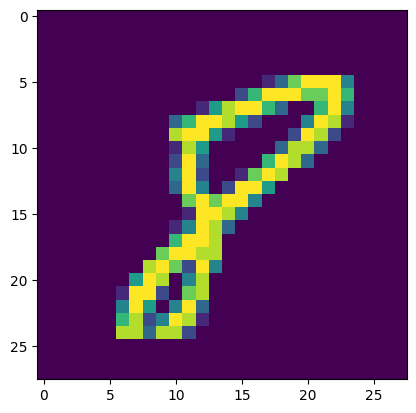

In [4]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

In [30]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [61]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [62]:
X_train.shape

(33600, 784)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
# Very time taking prediction because we need to find nearest neighbors in 784 dimensional space for 32k points
y_pred = knn.predict(X_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.9544047619047619


### Using PCA

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [33]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
#PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=None)   # n_components = None takes default as original no of columns

In [35]:
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [36]:
X_train.shape

(33600, 784)

Still 784 columns because n_components=None returns original no of columns

In [37]:
pca = PCA(n_components=100)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [39]:
X_train_trf.shape

(33600, 100)

Only 100 columns returned now

In [41]:
knn = KNeighborsClassifier()

knn.fit(X_train_trf , y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
y_pred = knn.predict(X_test_trf)
accuracy_score(y_pred,y_test)

0.9544047619047619

We repeat these steps after changing n_components multiple times and then looking at their accuracy scores to determine which value of n_components works best for our dataframe and then train the model upon that value

In [43]:
# for i in range(1,784):
    # pca = PCA(n_components=i)
    # X_train_trf = pca.fit_transform(X_train)
    # X_test_trf = pca.transform(X_test)
    # knn = KNeighborsClassifier()
    # knn.fit(X_train_trf,y_train)
    # y_pred = knn.predict(X_test_trf)
    # print(accuracy_score(y_test,y_pred))

## Visualization

In [45]:
# transforming to a 2D coordinate system

pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

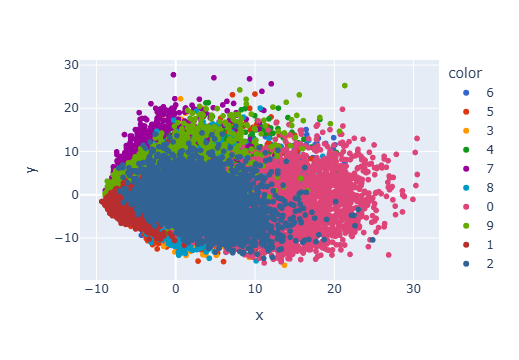

In [46]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                y=X_train_trf[:,1],
                color=y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [63]:
# transforming in 3D

pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

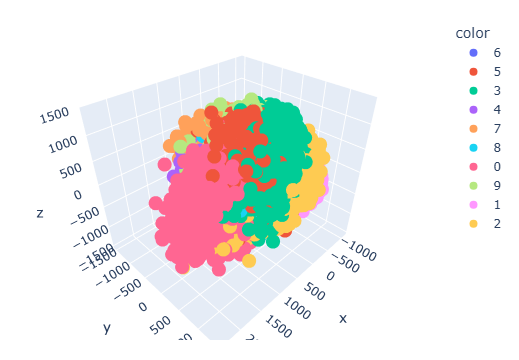

In [65]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(x=X_train_trf[:,0],
                y=X_train_trf[:,1],
                    z=X_train_trf[:,2],
                color=y_train_trf)
fig.update_layout(
    margin=dict(l=20,r=20,t=20,b=20)
)
fig.show()

In [68]:
pca.explained_variance_
# Eigen Values for the 3D data

array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [71]:
pca.components_.shape
# Eigen vectors given by pca.components_

(3, 784)

In [73]:
pca.explained_variance_ratio_
# Represents % value represented by each Eigen value

array([0.09770722, 0.07129345, 0.06175413])

In [74]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [75]:
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(784, 784))

In [76]:
pca.explained_variance_ratio_

array([9.77072202e-02, 7.12934512e-02, 6.17541312e-02, 5.38955140e-02,
       4.89255299e-02, 4.33684433e-02, 3.27657386e-02, 2.89270270e-02,
       2.77070300e-02, 2.32917149e-02, 2.09310651e-02, 2.04716403e-02,
       1.70779469e-02, 1.68320607e-02, 1.58472125e-02, 1.48798267e-02,
       1.32309818e-02, 1.28393670e-02, 1.18338358e-02, 1.15118647e-02,
       1.07596902e-02, 1.02421519e-02, 9.66625789e-03, 9.17296381e-03,
       8.84714420e-03, 8.33528008e-03, 8.15070612e-03, 7.75332066e-03,
       7.41986542e-03, 6.93325236e-03, 6.60848230e-03, 6.33209492e-03,
       6.03213006e-03, 5.88730096e-03, 5.61830060e-03, 5.39860932e-03,
       5.07909781e-03, 4.87126968e-03, 4.71252924e-03, 4.64556419e-03,
       4.52489910e-03, 4.44058540e-03, 4.16518263e-03, 3.95636411e-03,
       3.83603691e-03, 3.73127577e-03, 3.60704723e-03, 3.48865016e-03,
       3.34199674e-03, 3.18010732e-03, 3.14204894e-03, 3.07234334e-03,
       2.92367086e-03, 2.86553852e-03, 2.79118328e-03, 2.69328579e-03,
      

In [77]:
np.cumsum(pca.explained_variance_ratio_)

array([0.09770722, 0.16900067, 0.2307548 , 0.28465032, 0.33357585,
       0.37694429, 0.40971003, 0.43863706, 0.46634409, 0.4896358 ,
       0.51056687, 0.53103851, 0.54811645, 0.56494851, 0.58079573,
       0.59567555, 0.60890653, 0.6217459 , 0.63357974, 0.6450916 ,
       0.65585129, 0.66609344, 0.6757597 , 0.68493267, 0.69377981,
       0.70211509, 0.7102658 , 0.71801912, 0.72543898, 0.73237223,
       0.73898072, 0.74531281, 0.75134494, 0.75723224, 0.76285054,
       0.76824915, 0.77332825, 0.77819952, 0.78291205, 0.78755761,
       0.79208251, 0.7965231 , 0.80068828, 0.80464464, 0.80848068,
       0.81221196, 0.815819  , 0.81930765, 0.82264965, 0.82582976,
       0.82897181, 0.83204415, 0.83496782, 0.83783336, 0.84062454,
       0.84331783, 0.84596712, 0.84853351, 0.85106204, 0.85351457,
       0.85592008, 0.85831105, 0.86057999, 0.86279635, 0.8649424 ,
       0.86700054, 0.86901774, 0.87098082, 0.87291702, 0.87479944,
       0.87665559, 0.87847316, 0.88022525, 0.88195105, 0.88360

The point where we get the cumsum of eigen value % as 90 is the optimum fit for n_components

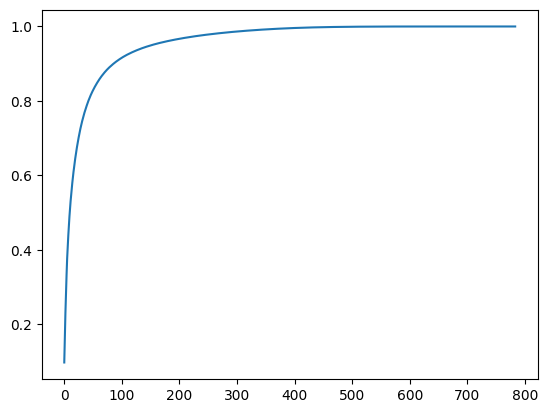

In [78]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))